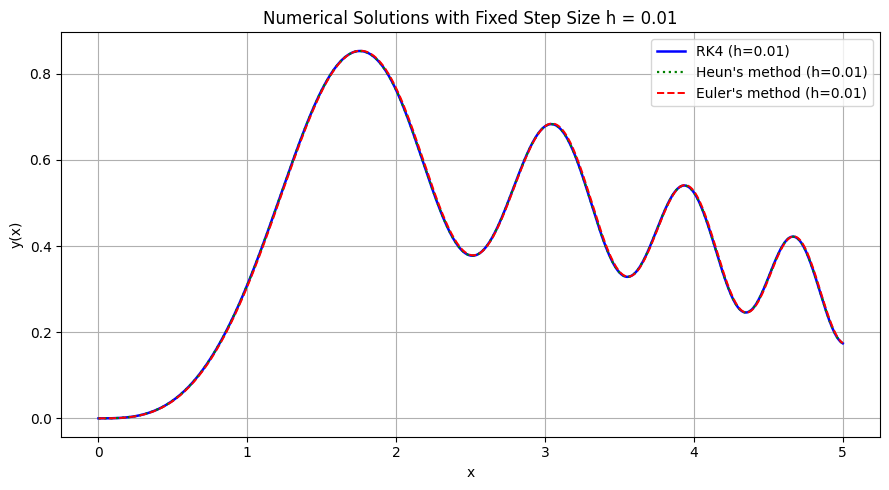

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -1/81 * x**3 * y**2 + np.sin(x**2) * np.cos(y**3)

# Parameters
h  = 0.01
x0, xN = 0.0, 5.0
y0 = 0.0
N  = int((xN - x0) / h)
xs = np.linspace(x0, xN, N + 1)

# Forward Euler
y_euler = np.zeros(N + 1)
y_euler[0] = y0
for i in range(N):
    y_euler[i+1] = y_euler[i] + h * f(xs[i], y_euler[i])

# Heun's Method
y_heun = np.zeros(N + 1)
y_heun[0] = y0
for i in range(N):
    k1 = f(xs[i], y_heun[i])
    k2 = f(xs[i] + h, y_heun[i] + h * k1)
    y_heun[i+1] = y_heun[i] + h/2 * (k1 + k2)

# RK4
y_rk4 = np.zeros(N + 1)
y_rk4[0] = y0
for i in range(N):
    k1 = f(xs[i], y_rk4[i])
    k2 = f(xs[i] + h/2, y_rk4[i] + h/2 * k1)
    k3 = f(xs[i] + h/2, y_rk4[i] + h/2 * k2)
    k4 = f(xs[i] + h, y_rk4[i] + h   * k3)
    y_rk4[i+1] = y_rk4[i] + h/6 * (k1 + 2*k2 + 2*k3 + k4)

plt.figure(figsize=(9, 5))
plt.plot(xs, y_rk4, 'b-', linewidth=1.8, label='RK4 (h=0.01)')
plt.plot(xs, y_heun, 'g:', linewidth=1.6, label="Heun's method (h=0.01)")
plt.plot(xs, y_euler, 'r--', linewidth=1.4, label="Euler's method (h=0.01)")

plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Numerical Solutions with Fixed Step Size h = 0.01')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()